# What is my task?

Mr Cj told me he needs to *Predict behavior to retain customers* and somone told him that computers are incredible for these kinda task.

# What data i have?

I have a dataset from [kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) which contains there columns: 

1. **customerID**: A unique id for each customer.

2. **gender**: Whether the customer is a male or a female.

3. **SeniorCitizen**: Whether the customer is a senior citizen or not (1, 0).

4. **Partner**: Whether the customer has a partner or not (Yes, No).

5. **Dependents**: Whether the customer has dependents or not (Yes, No).

6. **tenure**: Number of months the customer has stayed with the company.

7. **PhoneService**: Whether the customer has a phone service or not (Yes, No)

8. **MultipleLines**: Whether the customer has multiple lines or not (Yes, No, No phone service).

9. **InternetService**: Customer’s internet service provider (DSL, Fiber optic, No).

10. **OnlineSecurity**: Whether the customer has online security or not (Yes, No, No internet service).

11. **Churn**: Our target feature which is yes or no.

Each row represents a customer, each column contains customer’s attributes described on the column Metadata. Now let's make this dataset ready.

In [101]:
# ! curl -L -o ./telco-customer-churn.zip https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

In [102]:
# ! unzip ./telco-customer-churn.zip

# What is our metrics for this task?

I'll use common metrics such as **accuracy**, **precision**, **recall** ...

# Hands on Code!

## Import needed Libraries

In [103]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve
import joblib

RANDOM_SEED = 48731

## Load and Gain some info about Dataset

In [104]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We've got `7043` rows + `21 columns`, it seems like a larg dataset and it seems like we have no *null* columns, let's check it!

In [106]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Well i was right there is no *Null* fields in Dataset. BUT ix our dataset balanced? Let's find out ..

<Axes: >

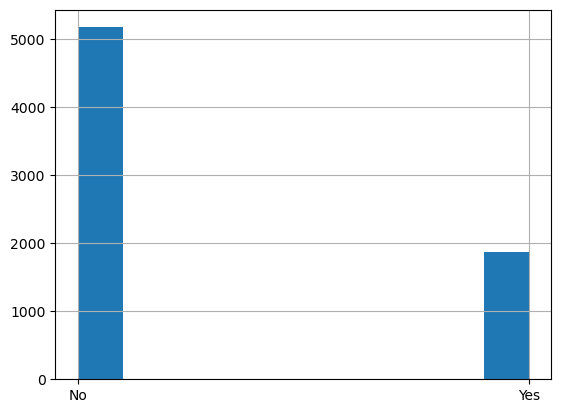

In [107]:
df.Churn.hist()

Oh HOLY Algorithm! we must use some balancing algorithms such as `ADASYN` ... move on next part of analyzing.

## Analayzing Features with type ...

### Numerical

feature `TotalCharges` is actully a numerical (float32) feature, we need to convert it! But **Please Note** in feature `TotalCharges` there are some space string, we shall handel it before convert it!.

In [108]:
floatList = []

for val in df['TotalCharges']: 
    try:
        floatList.append(float(val))
    except: 
        floatList.append(0.)

df['TotalCharges'] = floatList

df['TotalCharges'].astype("float32")

0         29.850000
1       1889.500000
2        108.150002
3       1840.750000
4        151.649994
           ...     
7038    1990.500000
7039    7362.899902
7040     346.450012
7041     306.600006
7042    6844.500000
Name: TotalCharges, Length: 7043, dtype: float32

In [109]:
num_cols = df.select_dtypes(exclude="object")

num_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

<Axes: >

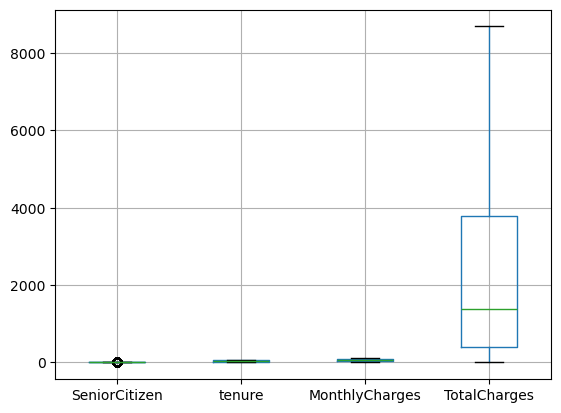

In [110]:
num_cols.boxplot()

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

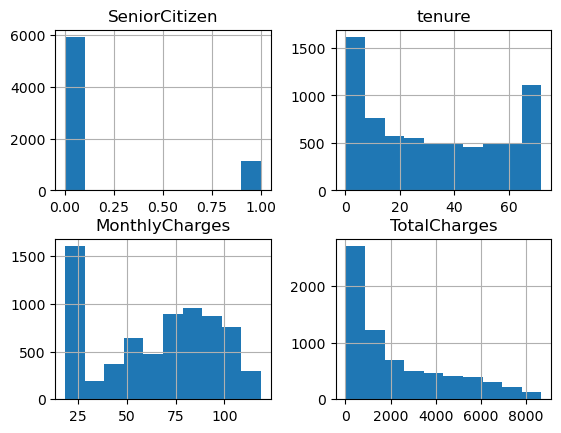

In [111]:
num_cols.hist()

at least, We have no outlier problems! Let's move into anayzing Categorical features!

**Note**: feature `SeniorCitizen` is a categorical feature which is only `1` or `0`...

### Categorical

In [112]:
cat_cols = df.select_dtypes(include="object")

In [113]:
cat_cols.nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [114]:
for col in cat_cols: 
    print(f"`{col}` unique values:")
    print(cat_cols[col].unique())
    print()

`customerID` unique values:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

`gender` unique values:
['Female' 'Male']

`Partner` unique values:
['Yes' 'No']

`Dependents` unique values:
['No' 'Yes']

`PhoneService` unique values:
['No' 'Yes']

`MultipleLines` unique values:
['No phone service' 'No' 'Yes']

`InternetService` unique values:
['DSL' 'Fiber optic' 'No']

`OnlineSecurity` unique values:
['No' 'Yes' 'No internet service']

`OnlineBackup` unique values:
['Yes' 'No' 'No internet service']

`DeviceProtection` unique values:
['No' 'Yes' 'No internet service']

`TechSupport` unique values:
['No' 'Yes' 'No internet service']

`StreamingTV` unique values:
['No' 'Yes' 'No internet service']

`StreamingMovies` unique values:
['No' 'Yes' 'No internet service']

`Contract` unique values:
['Month-to-month' 'One year' 'Two year']

`PaperlessBilling` unique values:
['Yes' 'No']

`PaymentMethod` unique values:
['Electronic check' 'Mailed check' 'Bank tr

## Feature selection

In [115]:
df = df.drop(columns=["customerID"])

cat_cols = df.select_dtypes(include="object")

df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


From there features we don't need `customerID` so i removed it. Now i want to *Label Encode* dataset *object* type features to continue my feature selection part.

### Label Encode `object` type features

In [116]:
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


### Check features Correlation

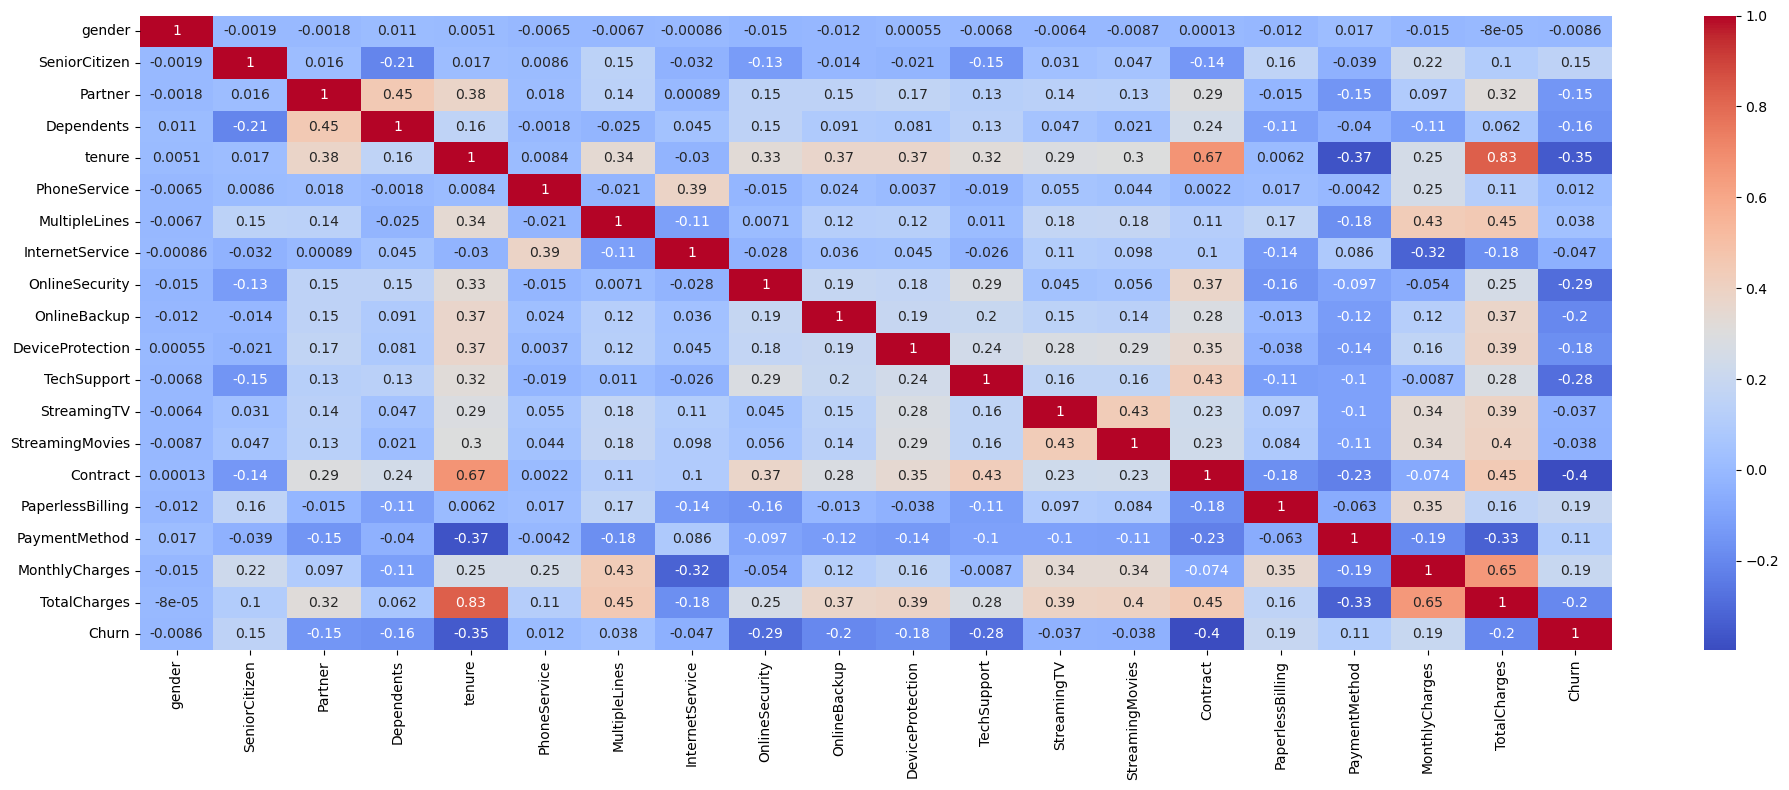

In [117]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=df.corr(), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()

In [118]:
df = df.drop(columns=["tenure"])

From correlation heatmap above, decided to remove feature `tenure` .

## Feature Engineering

### Robust scale numerical features

In [119]:
num_cols = df.select_dtypes(exclude="int64")
num_cols

,MonthlyCharges,TotalCharges
0,29.85,29.85
1,56.95,1889.50
2,53.85,108.15
3,42.30,1840.75
4,70.70,151.65
...,...,...
7038,84.80,1990.50
7039,103.20,7362.90
7040,29.60,346.45
7041,74.40,306.60


In [120]:
rb = RobustScaler()
for col in num_cols:
    df[col] = rb.fit_transform(pd.DataFrame(df[col]))

### One hot encode categorical features

In [121]:
cat_features_name = df.select_dtypes(include="int").drop(columns=["Churn"]).columns

ohe = OneHotEncoder()
transformer = ColumnTransformer( [(
    "one-hot",
    ohe,
    cat_features_name
)], remainder="passthrough")

In [122]:
X = pd.DataFrame(transformer.fit_transform(df.drop(columns=["Churn"])))
y = df.Churn

### Handel imbalance data

In [123]:
adasyn = ADASYN(random_state=RANDOM_SEED, n_neighbors=7)
X_resampled, y_resampled= adasyn.fit_resample(X, y)

<Axes: >

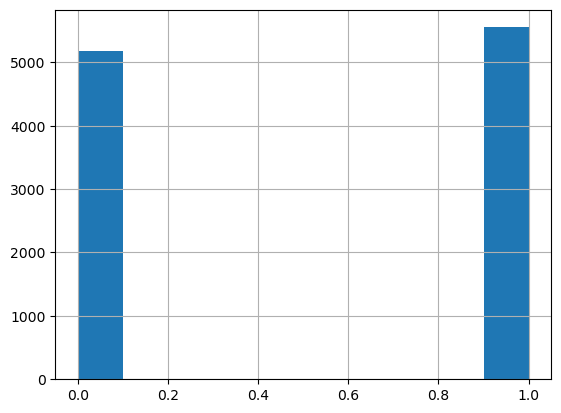

In [124]:
y_resampled.hist()

It was very Easy (thanks to python!)

### Let's now train, test split data

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=RANDOM_SEED)

## Model design

### Setup some evaluation functions

In [126]:
def evaluateModel(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {
        "accuracy": acc,
        "precision": prec,
        "recall":recall,
        "f1_score": f1
    }


In [127]:
def KFoldCrossValidation(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"accuracy for each fold: {scores}")
    average_accuracy = np.mean(scores)
    print(f"mean accuracy: {average_accuracy:.2f}")

In [128]:
def plot_roc_curve(model, X_test):
    # getting probabilities
    y_probs = model.predict_proba(X_test)
    y_probs_positive = y_probs[:, 1]
    y_probs_negative = y_probs[:, 0]

    # calculate roc curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

    # plot ROC curve
    plt.plot(fpr, tpr, color='orange', label='ROC')
    # plot the base line 
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Gussing')
    # plot best AUC score 
    t1, t2, _ = roc_curve(y_test, y_test)
    plt.plot(t1, t2, color='green', linestyle='--', label='best score')

    # customize plot 
    plt.xlabel('False Positive Rate (fpr)')
    plt.ylabel('True Positive Rate (tpr)')
    plt.title('Reciver Operating Characteristic (ROC) curve')
    plt.legend()
    plt.show()

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      1030
           1       0.78      0.87      0.82      1116

    accuracy                           0.81      2146
   macro avg       0.81      0.80      0.80      2146
weighted avg       0.81      0.81      0.80      2146



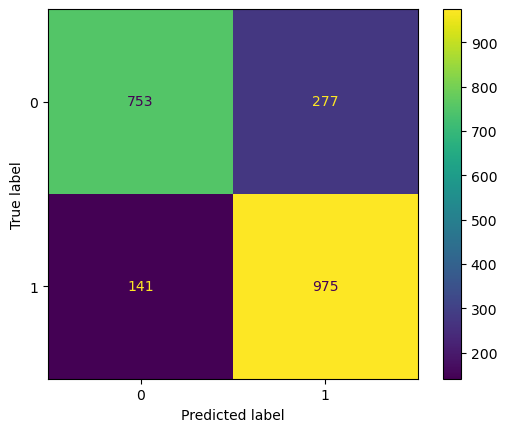

accuracy for each fold: [0.79347055 0.80269695 0.80908446 0.78267045 0.79971591]
mean accuracy: 0.80


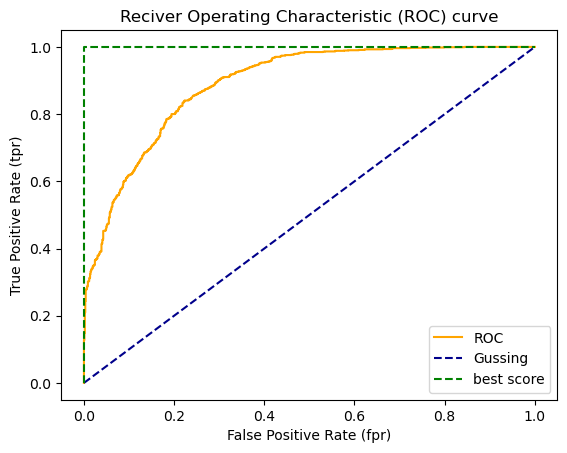

In [129]:
model_svc = SVC(random_state=RANDOM_SEED, kernel="rbf", probability=True)
model_svc.fit(X_train, y_train)

y_pred = model_svc.predict(X_test)
evaluateModel(model_svc, X_test, y_test)
KFoldCrossValidation(model_svc, X, y)
plot_roc_curve(model_svc, X_test)

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1030
           1       0.85      0.88      0.86      1116

    accuracy                           0.85      2146
   macro avg       0.85      0.85      0.85      2146
weighted avg       0.85      0.85      0.85      2146



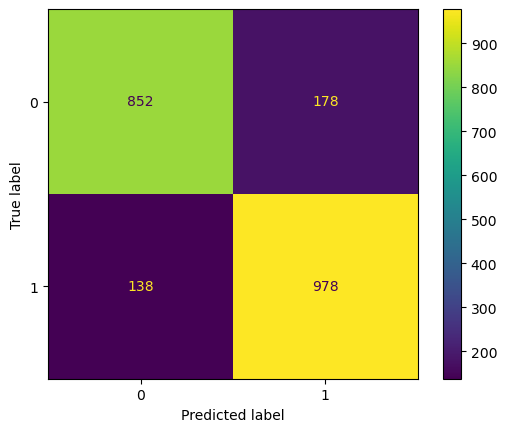

accuracy for each fold: [0.7828247  0.78211498 0.78779276 0.77059659 0.78977273]
mean accuracy: 0.78


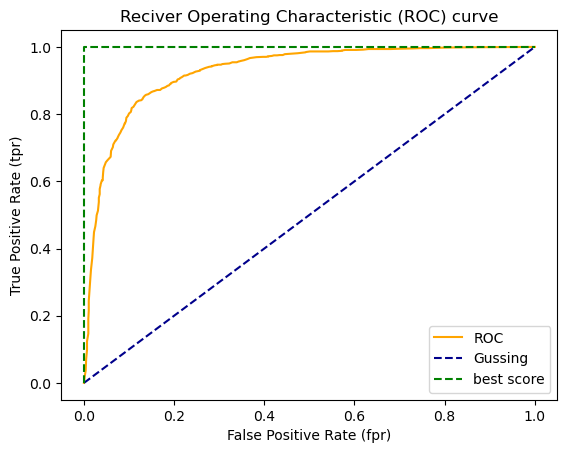

In [130]:
model_rfc = RandomForestClassifier(n_estimators=150, random_state=RANDOM_SEED)
model_rfc.fit(X_train, y_train)

y_pred = model_rfc.predict(X_test)
evaluateModel(model_rfc, X_test, y_test)
KFoldCrossValidation(model_rfc, X, y)
plot_roc_curve(model_rfc, X_test)

              precision    recall  f1-score   support

           0       0.73      0.67      0.70      1030
           1       0.71      0.78      0.74      1116

    accuracy                           0.72      2146
   macro avg       0.72      0.72      0.72      2146
weighted avg       0.72      0.72      0.72      2146



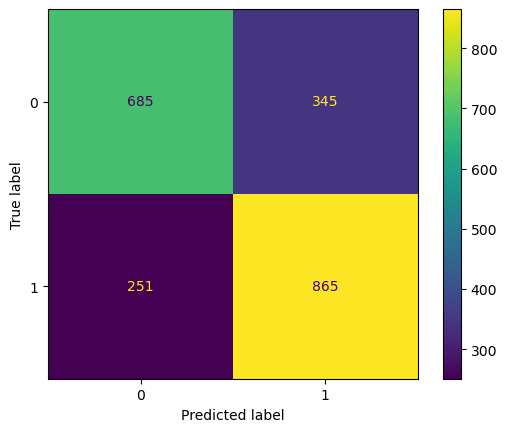

accuracy for each fold: [0.78921221 0.80411639 0.81476224 0.78693182 0.80397727]
mean accuracy: 0.80


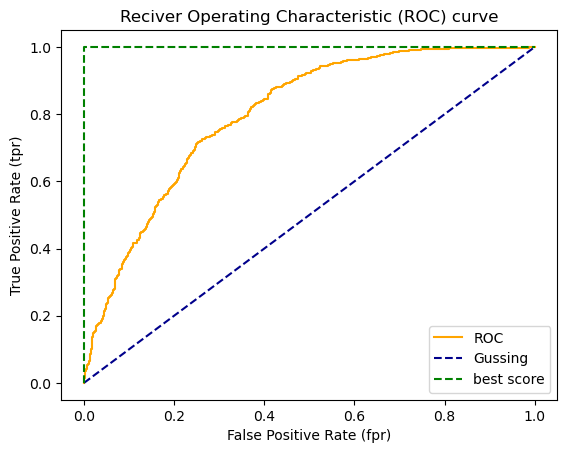

In [131]:
model_lgr = LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)
model_lgr.fit(X_train, y_train)

y_pred = model_lgr.predict(X_test)
evaluateModel(model_lgr, X_test, y_test)
KFoldCrossValidation(model_lgr, X, y)
plot_roc_curve(model_lgr, X_test)

First i used `max_iter=100` but it says increase it so i use `5000` for it.

## Save best model

In [132]:
MODEL_NAME = "rfc_predictor."

In [133]:
joblib.dump(model_rfc, f"{MODEL_NAME}.pkl")

['rfc_predictor..pkl']

In [134]:
model = joblib.load(f"{MODEL_NAME}.pkl")